# Speed Breaker Detection using Deep Learning

This project detects road speed breakers from images using a MobileNetV2 deep learning model.

Author: Harsh Mishra


## 1. Install Dependencies

In [1]:
!pip install tensorflow opencv-python matplotlib scikit-learn

## 2. Mount Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Dataset Setup

In [3]:
DATASET_PATH = "/content/drive/MyDrive/dataset"

## 4. Import Libraries

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

## 5. Data Preprocessing

In [5]:
IMG_SIZE = (224,224)
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training"
)

val_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation"
)

Found 2184 images belonging to 2 classes.
Found 545 images belonging to 2 classes.


## 6. Model Architecture

In [6]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

## 7. Compile Model

In [8]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## 8. Model Training

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 882s 12s/step - accuracy: 0.9506 - loss: 0.0870 - val_accuracy: 0.5743 - val_loss: 13.9265
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 30s 435ms/step - accuracy: 0.9957 - loss: 0.0197 - val_accuracy: 0.4972 - val_loss: 11.8643
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 30s 438ms/step - accuracy: 0.9931 - loss: 0.0253 - val_accuracy: 0.6697 - val_loss: 4.8947
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 29s 415ms/step - accuracy: 0.9970 - loss: 0.0077 - val_accuracy: 0.9266 - val_loss: 0.5962
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 29s 417ms/step - accuracy: 0.9905 - loss: 0.0342 - val_accuracy: 0.5083 - val_loss: 8.7042
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 29s 424ms/step - accuracy: 0.9978 - loss: 0.0150 - val_accuracy: 0.5083 - val_loss: 14.3222
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 29s 424ms/step - accuracy: 0.9999 - loss: 8.8892e-04 - val_accuracy: 0.5174 - val_loss: 10.3767
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 29s 425ms/step - accuracy: 1.0000 - loss: 0.0013 - v

## 9. Training Results


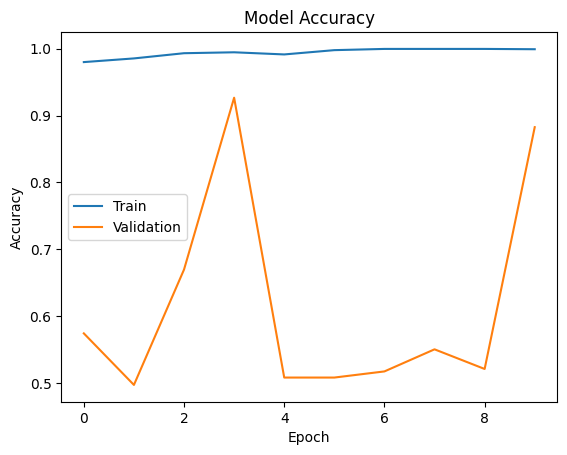

In [12]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(["Train", "Validation"])
plt.show()

## 10. Save Model

In [13]:
model.save("/content/drive/MyDrive/speedbreaker_model.h5")